In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the sgr set you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}_+$

In [2]:
sgr_df = pickle.load(open('sgr_set_cnn','rb')) 
print(sgr_df.shape)
print('Propotion of 1s: ', np.round(sgr_df.y_true.sum()/sgr_df.shape[0],2))
sgr_df.head() 

(7606, 3)
Propotion of 1s:  0.37


,y_true,y_pred,kappa
0,0.0,0.0,0.999059
1,0.0,0.0,0.998298
2,1.0,1.0,0.813116
3,1.0,1.0,0.978369
4,0.0,0.0,0.979148


In [3]:
delta = 0.01
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds
metric_targets=[i/1000 for i in integers_exp_spacing(5,300)]
proportions_1 = np.linspace(0.01,0.5,15) # for classes imbalance impact study

In [4]:
train_set = sgr_df.iloc[:int(len(sgr_df)/2)]
train_set = train_set.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[int(len(sgr_df)/2):]

## <font color = 'yellow'> 1. __0/1 risk__ 
Dichotomy search for upper bound

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.004271,0.980991,0.000000,0.282935,0.000000,0.324481
1,0.006,0.005773,0.979248,0.000872,0.301604,0.000000,0.342624
2,0.007,0.005773,0.979248,0.000872,0.301604,0.000000,0.342624
3,0.008,0.006799,0.971819,0.002035,0.387589,0.001287,0.408625
4,0.009,0.009429,0.969429,0.003894,0.405206,0.001854,0.425454
5,0.010,0.010385,0.964910,0.004788,0.439390,0.002890,0.454904
6,0.011,0.011530,0.961838,0.005741,0.458059,0.005540,0.474625
7,0.013,0.013165,0.958041,0.007112,0.480673,0.005823,0.496713
8,0.016,0.016411,0.952820,0.009824,0.508546,0.006477,0.527741
9,0.018,0.018275,0.948823,0.011448,0.528267,0.006699,0.549566


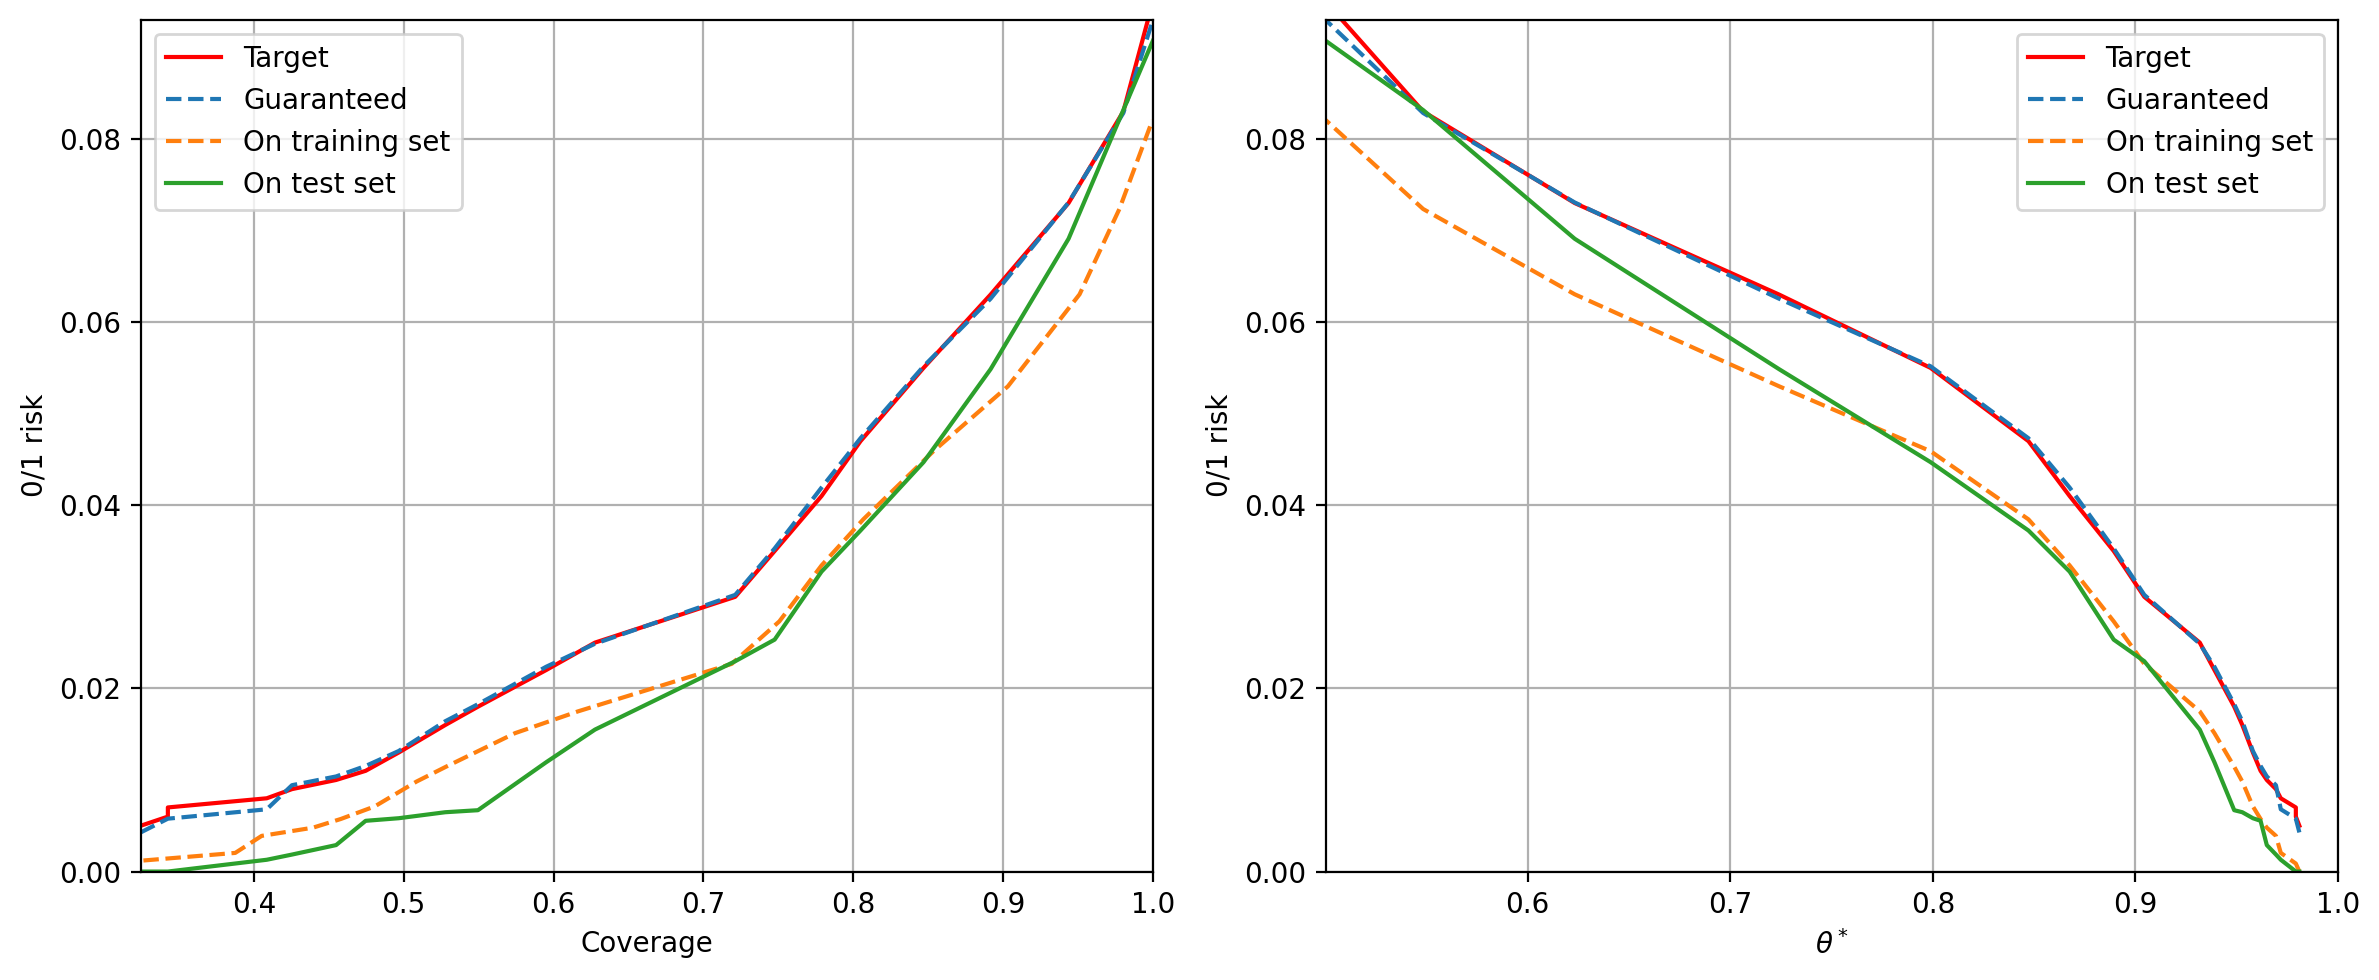

In [5]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, mode='dicho')
display(results)
metric_plots(results, ylabel='0/1 risk', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

## <font color = 'yellow'> 2. __FPP/FNP__
Dichotomy search for upper bound

### <font color = 'orange'> 2.1. __FPP__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.004271,0.980991,0.000000,0.282935,0.000000,0.324481
1,0.006,0.005773,0.979248,0.000872,0.301604,0.000000,0.342624
2,0.007,0.005773,0.979248,0.000872,0.301604,0.000000,0.342624
3,0.008,0.006799,0.971819,0.002035,0.387589,0.001287,0.408625
4,0.009,0.009549,0.964910,0.004189,0.439390,0.002890,0.454904
5,0.010,0.009465,0.964116,0.004152,0.443334,0.003998,0.460426
6,0.011,0.011291,0.959759,0.005621,0.467789,0.005956,0.485669
7,0.013,0.012400,0.957809,0.006540,0.482514,0.005811,0.497765
8,0.016,0.016424,0.948823,0.009955,0.528267,0.006699,0.549566
9,0.018,0.018020,0.943402,0.011396,0.553773,0.010096,0.572969


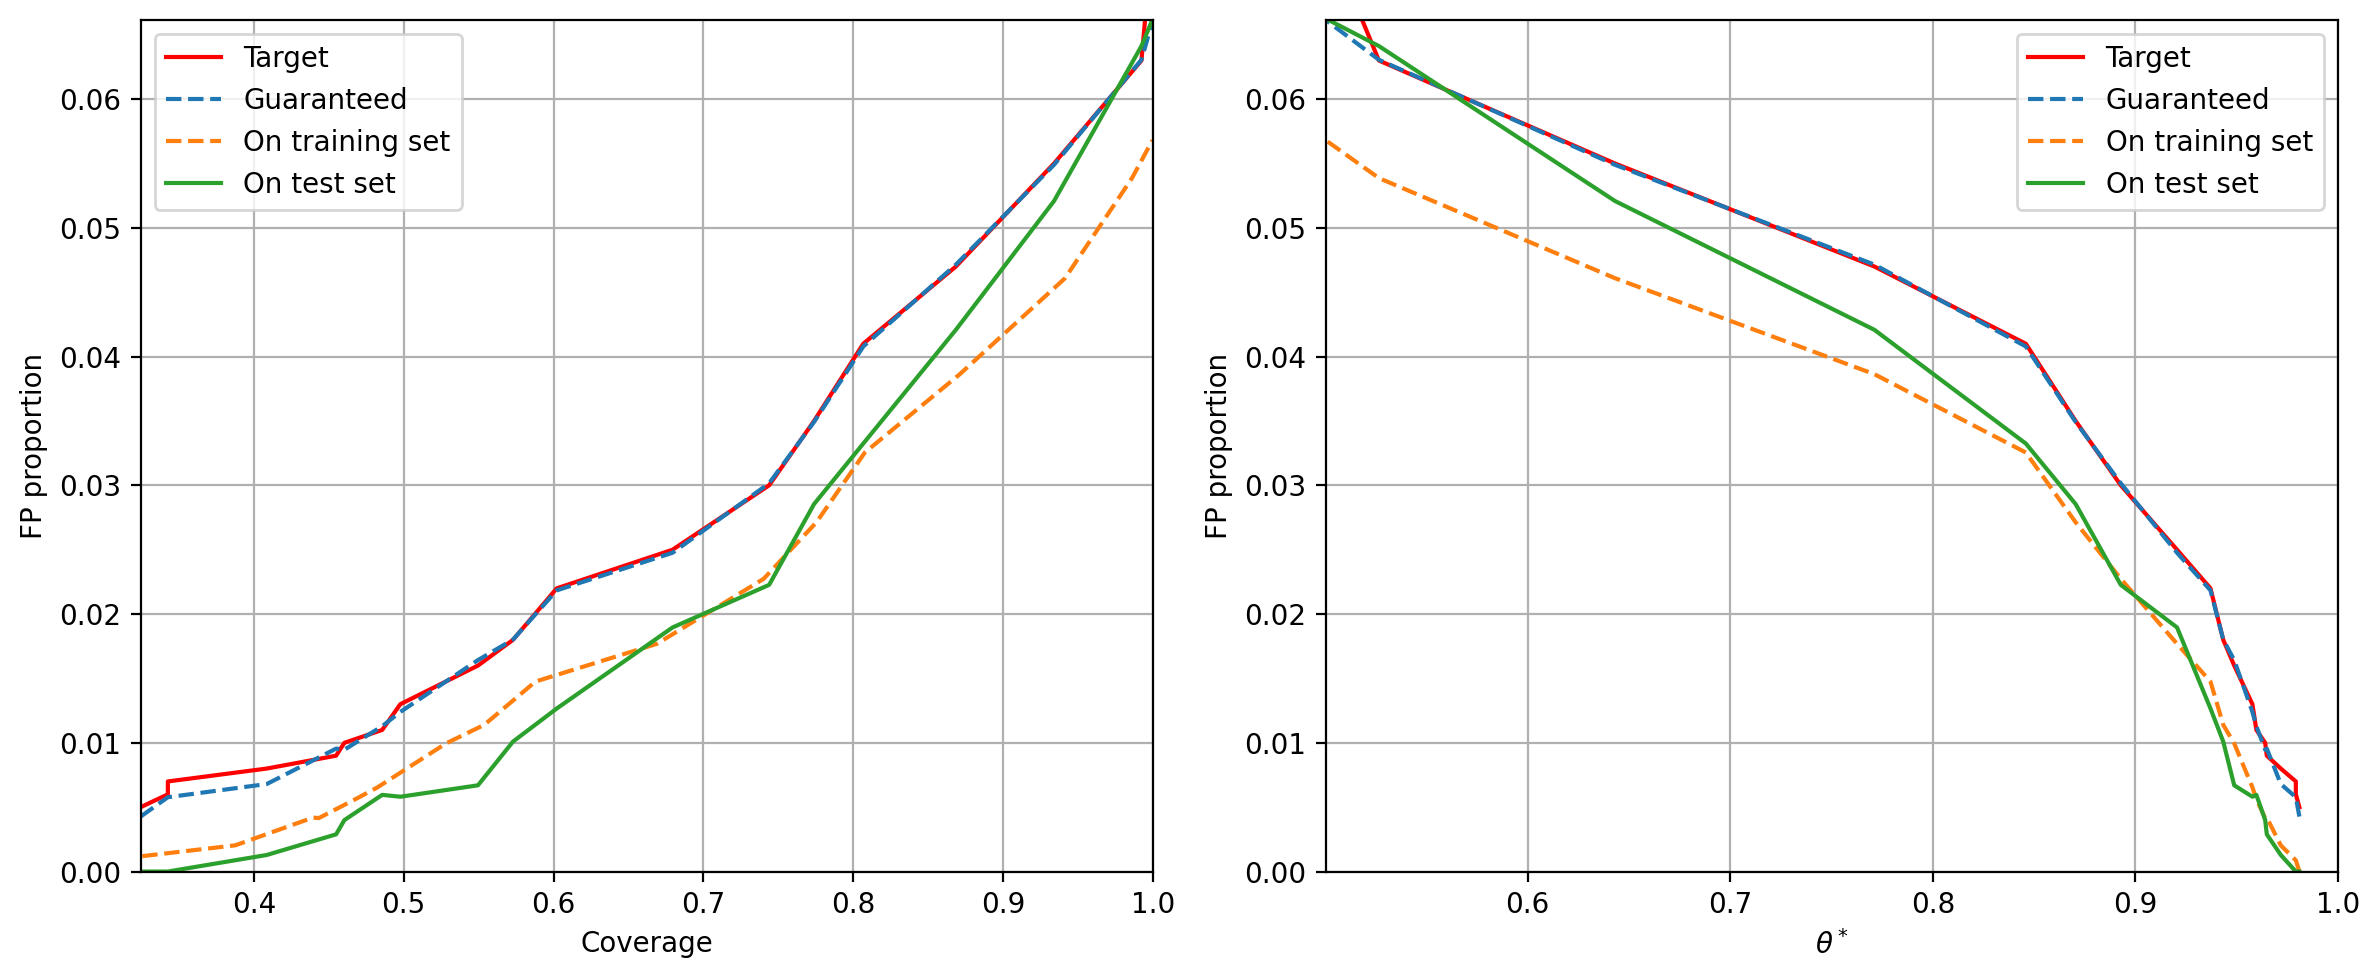

In [6]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric='FP', mode='dicho')
display(results)
metric_plots(results, ylabel='FP proportion', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

### <font color = 'orange'> 2.2. __FNP__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.005069,0.917406,0.001936,0.678938,0.001148,0.687352
1,0.006,0.006313,0.902224,0.002907,0.723639,0.002172,0.726269
2,0.007,0.006670,0.893211,0.003202,0.739153,0.002480,0.742309
3,0.008,0.007714,0.869460,0.004064,0.776492,0.003385,0.776755
4,0.009,0.009444,0.867584,0.005402,0.778859,0.003376,0.778859
5,0.010,0.009288,0.856702,0.005312,0.792006,0.003981,0.792532
6,0.011,0.011298,0.854030,0.006922,0.797791,0.004293,0.796214
7,0.013,0.012922,0.805146,0.008375,0.847752,0.006567,0.840915
8,0.016,0.015442,0.737625,0.010594,0.893505,0.008289,0.888246
9,0.018,0.017821,0.668187,0.012715,0.930581,0.013143,0.920326


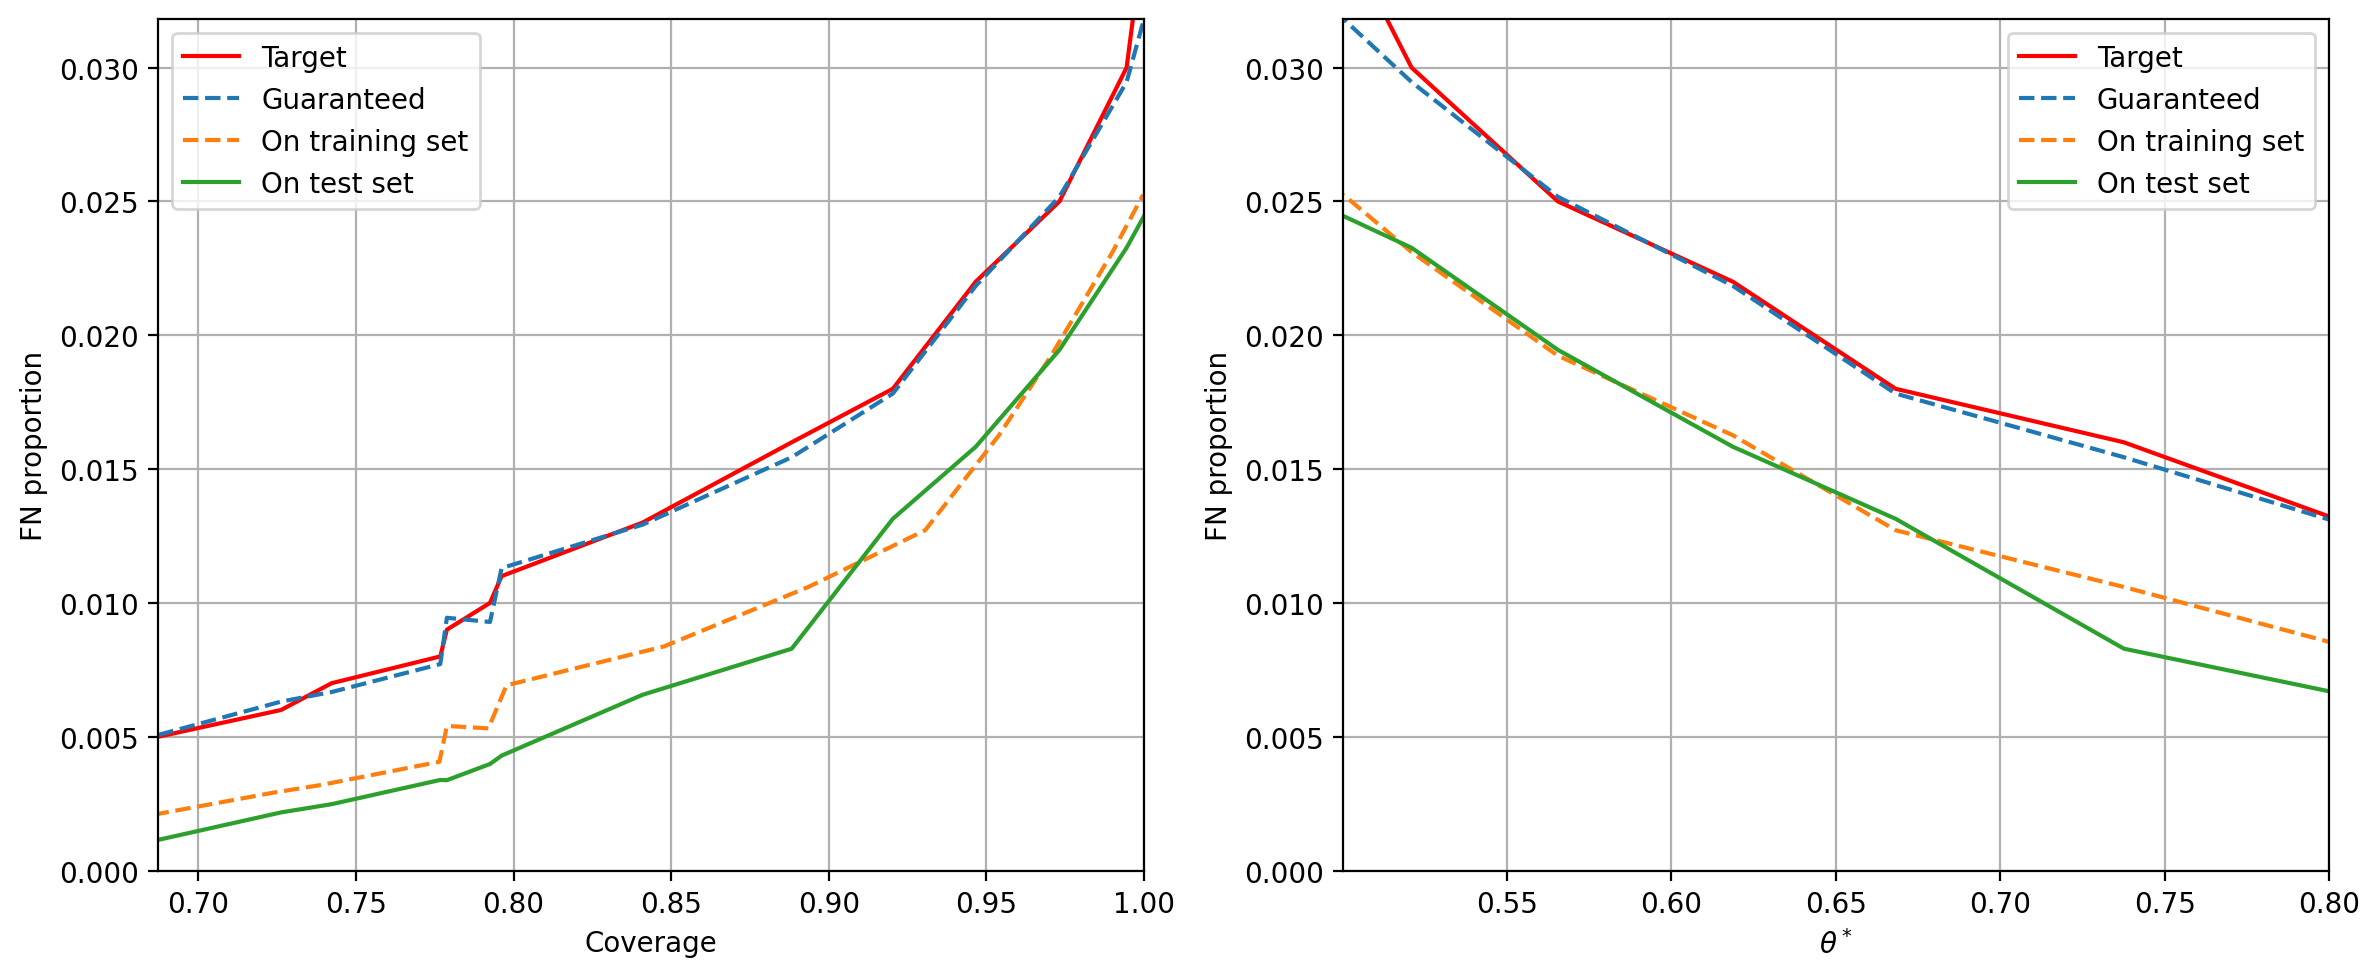

In [7]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FN', mode='dicho')
display(results)
metric_plots(results, ylabel='FN proportion', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),0.8], ylim=[0,max(results.metric_bound)])

## <font color = 'yellow'> __3. Conditional metrics__

### <font color = 'orange'> 3.1. __FPR__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.007,0.007611,0.979589,0.000988,0.298974,0.000000,0.339469
1,0.008,0.007611,0.979589,0.000988,0.298974,0.000000,0.339469
2,0.009,0.007611,0.979589,0.000988,0.298974,0.000000,0.339469
3,0.010,0.007611,0.979589,0.000988,0.298974,0.000000,0.339469
4,0.011,0.007611,0.979589,0.000988,0.298974,0.000000,0.339469
5,0.013,0.012938,0.969385,0.004743,0.405732,0.002094,0.426242
6,0.016,0.016991,0.959182,0.007840,0.472522,0.007006,0.490928
7,0.018,0.016991,0.959182,0.007840,0.472522,0.007006,0.490928
8,0.022,0.016991,0.959182,0.007840,0.472522,0.007006,0.490928
9,0.025,0.023409,0.948978,0.012684,0.526952,0.008343,0.548777


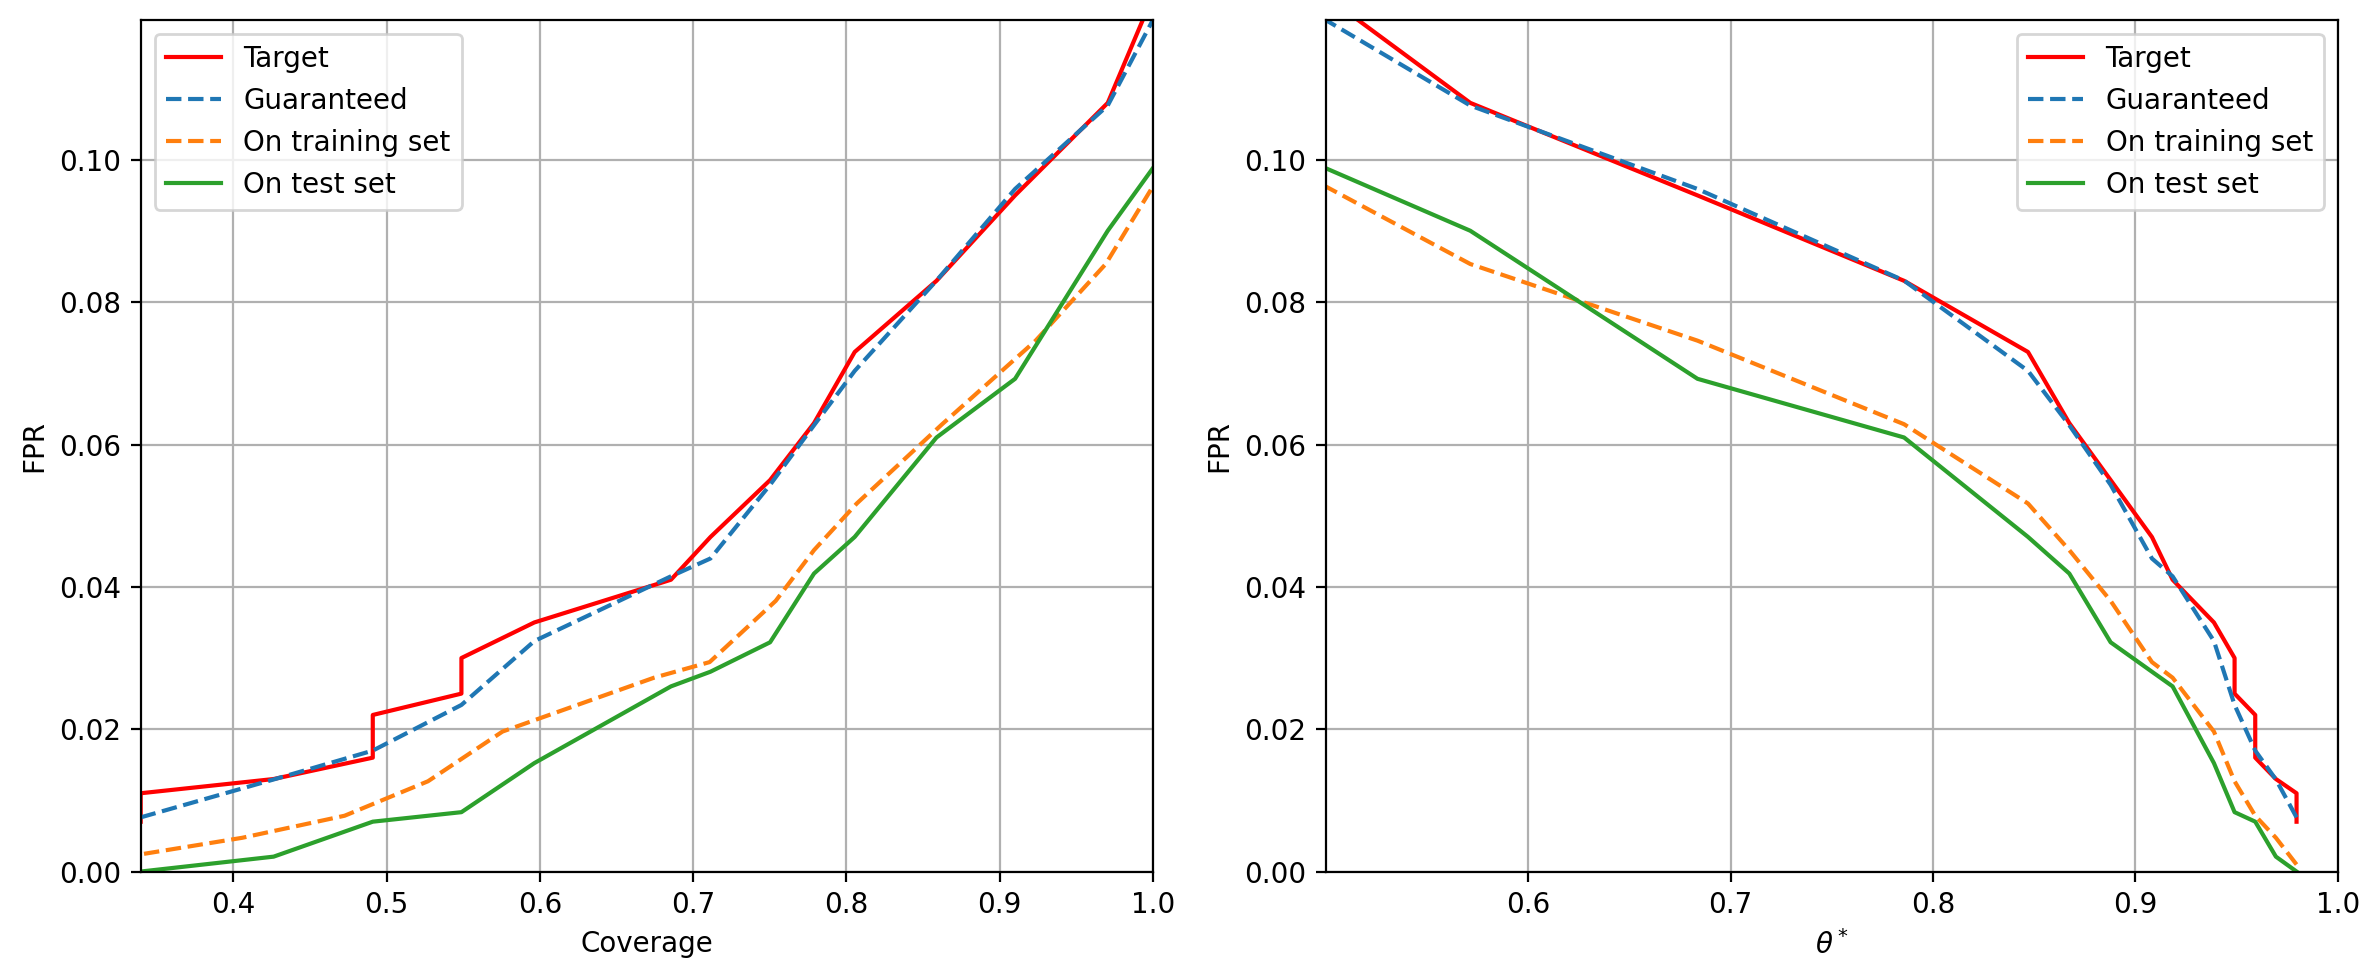

In [8]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FPR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FPR', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

### <font color = 'orange'> 3.2. __FNR__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.016,0.015786,0.918368,0.004566,0.674468,0.004380,0.685511
1,0.018,0.015786,0.918368,0.004566,0.674468,0.004380,0.685511
2,0.022,0.022205,0.877554,0.009928,0.768867,0.010514,0.763871
3,0.025,0.022205,0.877554,0.009928,0.768867,0.010514,0.763871
4,0.030,0.027723,0.857147,0.013901,0.791217,0.013230,0.791480
5,0.035,0.034193,0.836740,0.018899,0.817775,0.019979,0.814094
6,0.041,0.041692,0.744908,0.025510,0.888772,0.026071,0.884039
7,0.047,0.047701,0.704094,0.030389,0.912438,0.034296,0.901920
8,0.055,0.050197,0.632669,0.032698,0.945306,0.044789,0.939521
9,0.063,0.061679,0.581652,0.041972,0.965028,0.055927,0.966605


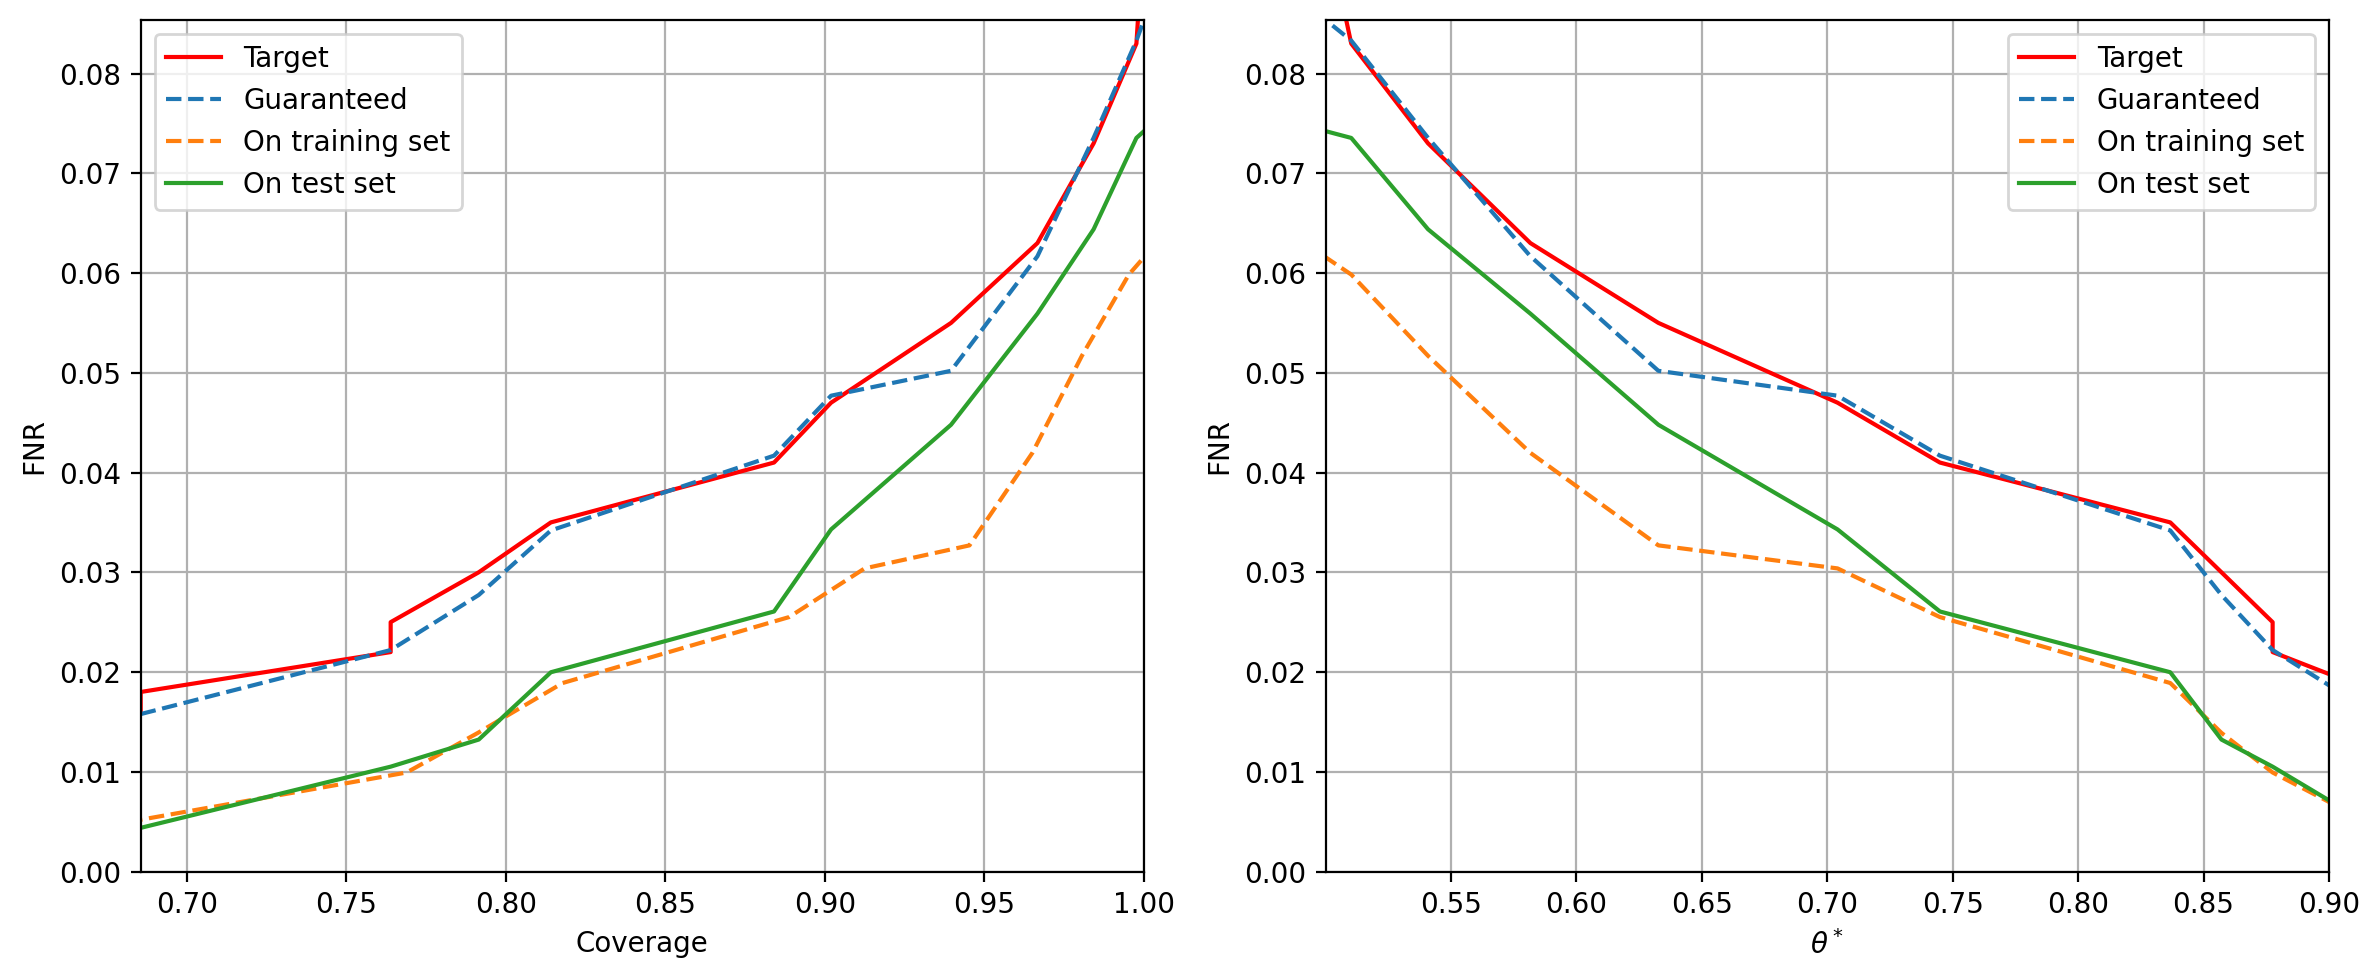

In [9]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FNR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FNR', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),0.9], ylim=[0,max(results.metric_bound)])

### <font color = 'orange'> 3.3. __PPV__

In [10]:
metric_targets=[i/1000 for i in integers_log_spacing(700,1000)]

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
1,0.730,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
2,0.757,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
3,0.782,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
4,0.805,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
5,0.827,0.836376,0.500024,0.871352,1.000000,0.821530,1.000000
6,0.846,0.845743,0.530634,0.879686,0.984223,0.827834,0.989745
7,0.864,0.863619,0.642873,0.895768,0.941362,0.856366,0.933999
8,0.880,0.879588,0.775519,0.911189,0.868788,0.880172,0.866158
9,0.895,0.898624,0.867350,0.930311,0.778859,0.909469,0.778859


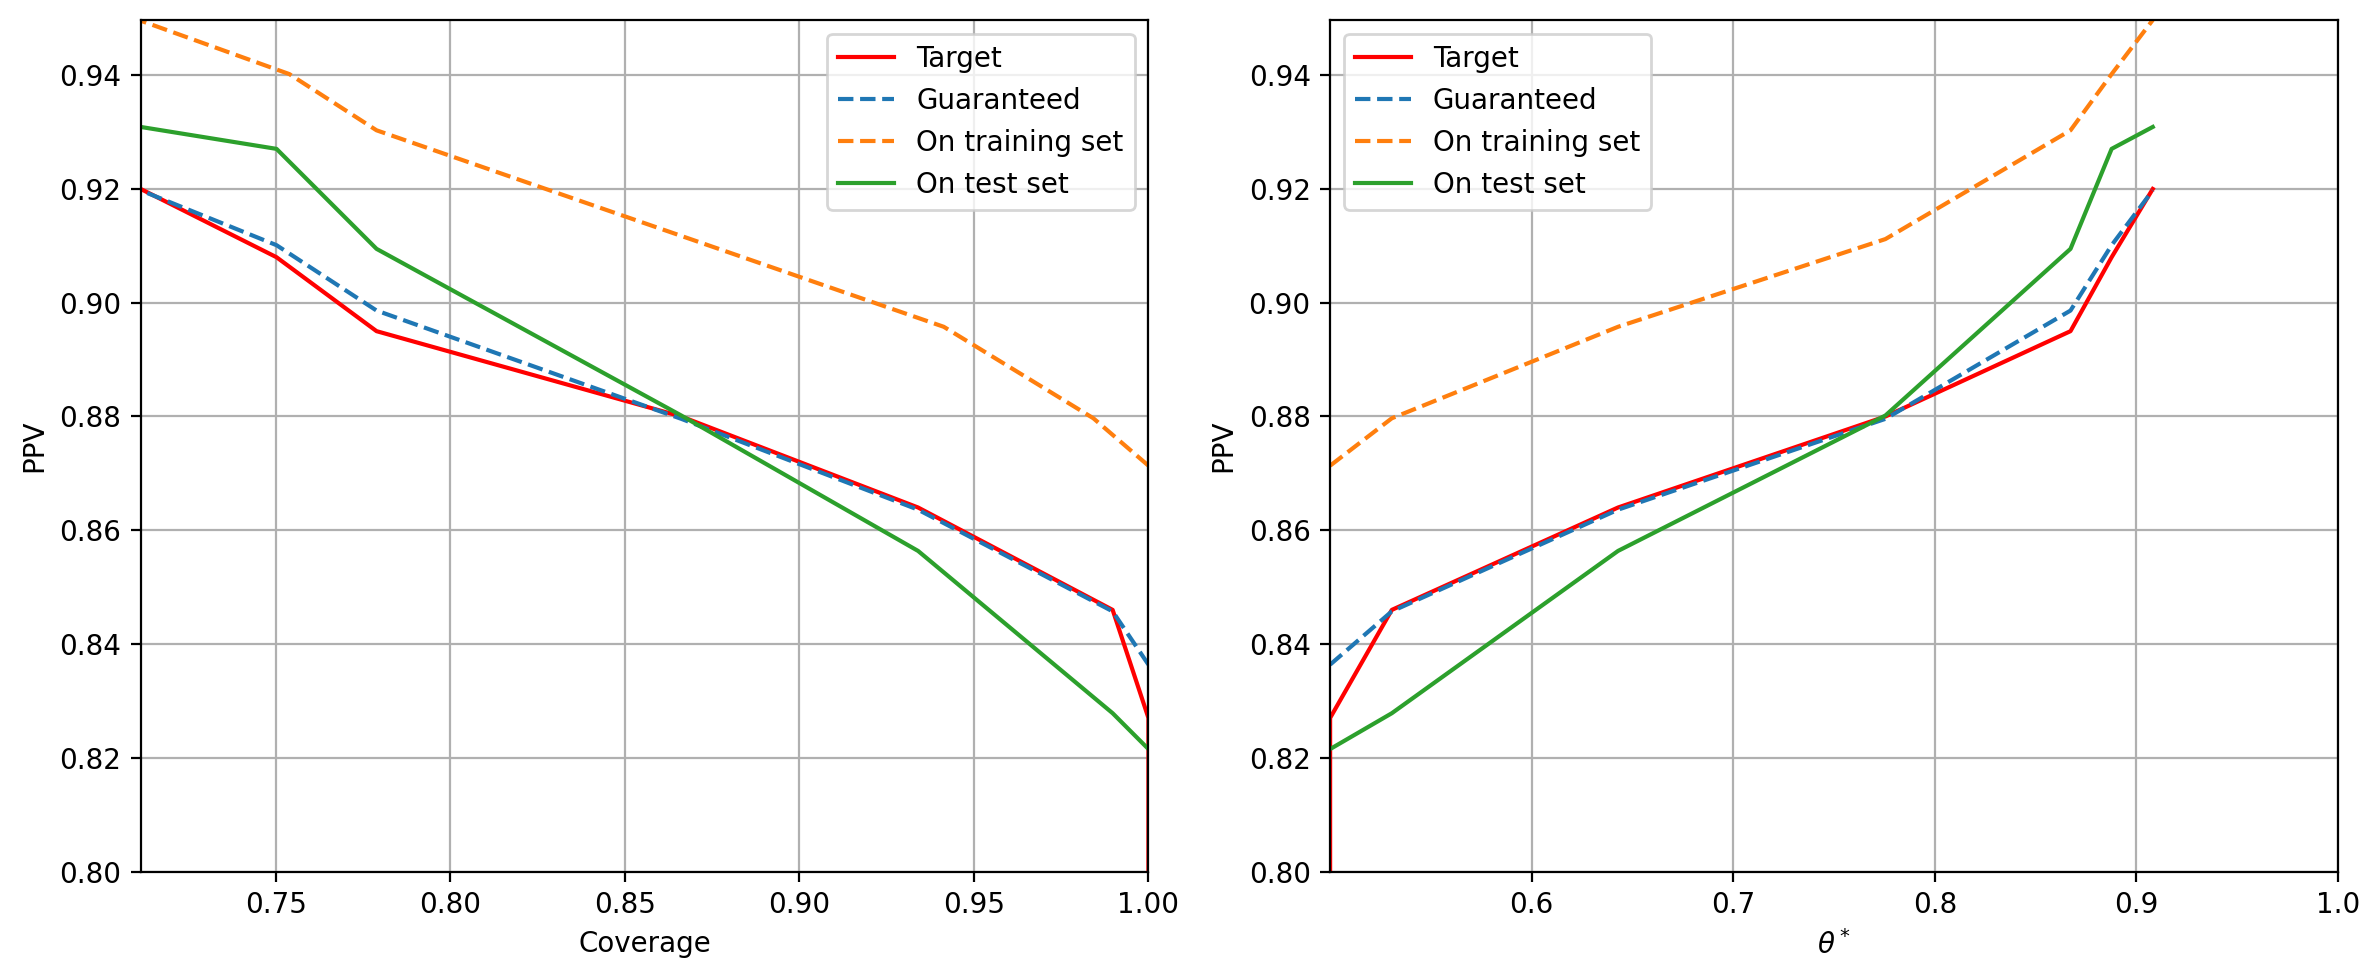

In [11]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'PPV', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='PPV', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0.8, max(results.train_metric)])

### <font color = 'orange'> 3.4. __SE__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
1,0.730,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
2,0.757,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
3,0.782,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
4,0.805,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
5,0.827,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
6,0.846,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
7,0.864,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
8,0.880,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000
9,0.895,0.914636,0.500024,0.938422,1.000000,0.925778,1.000000


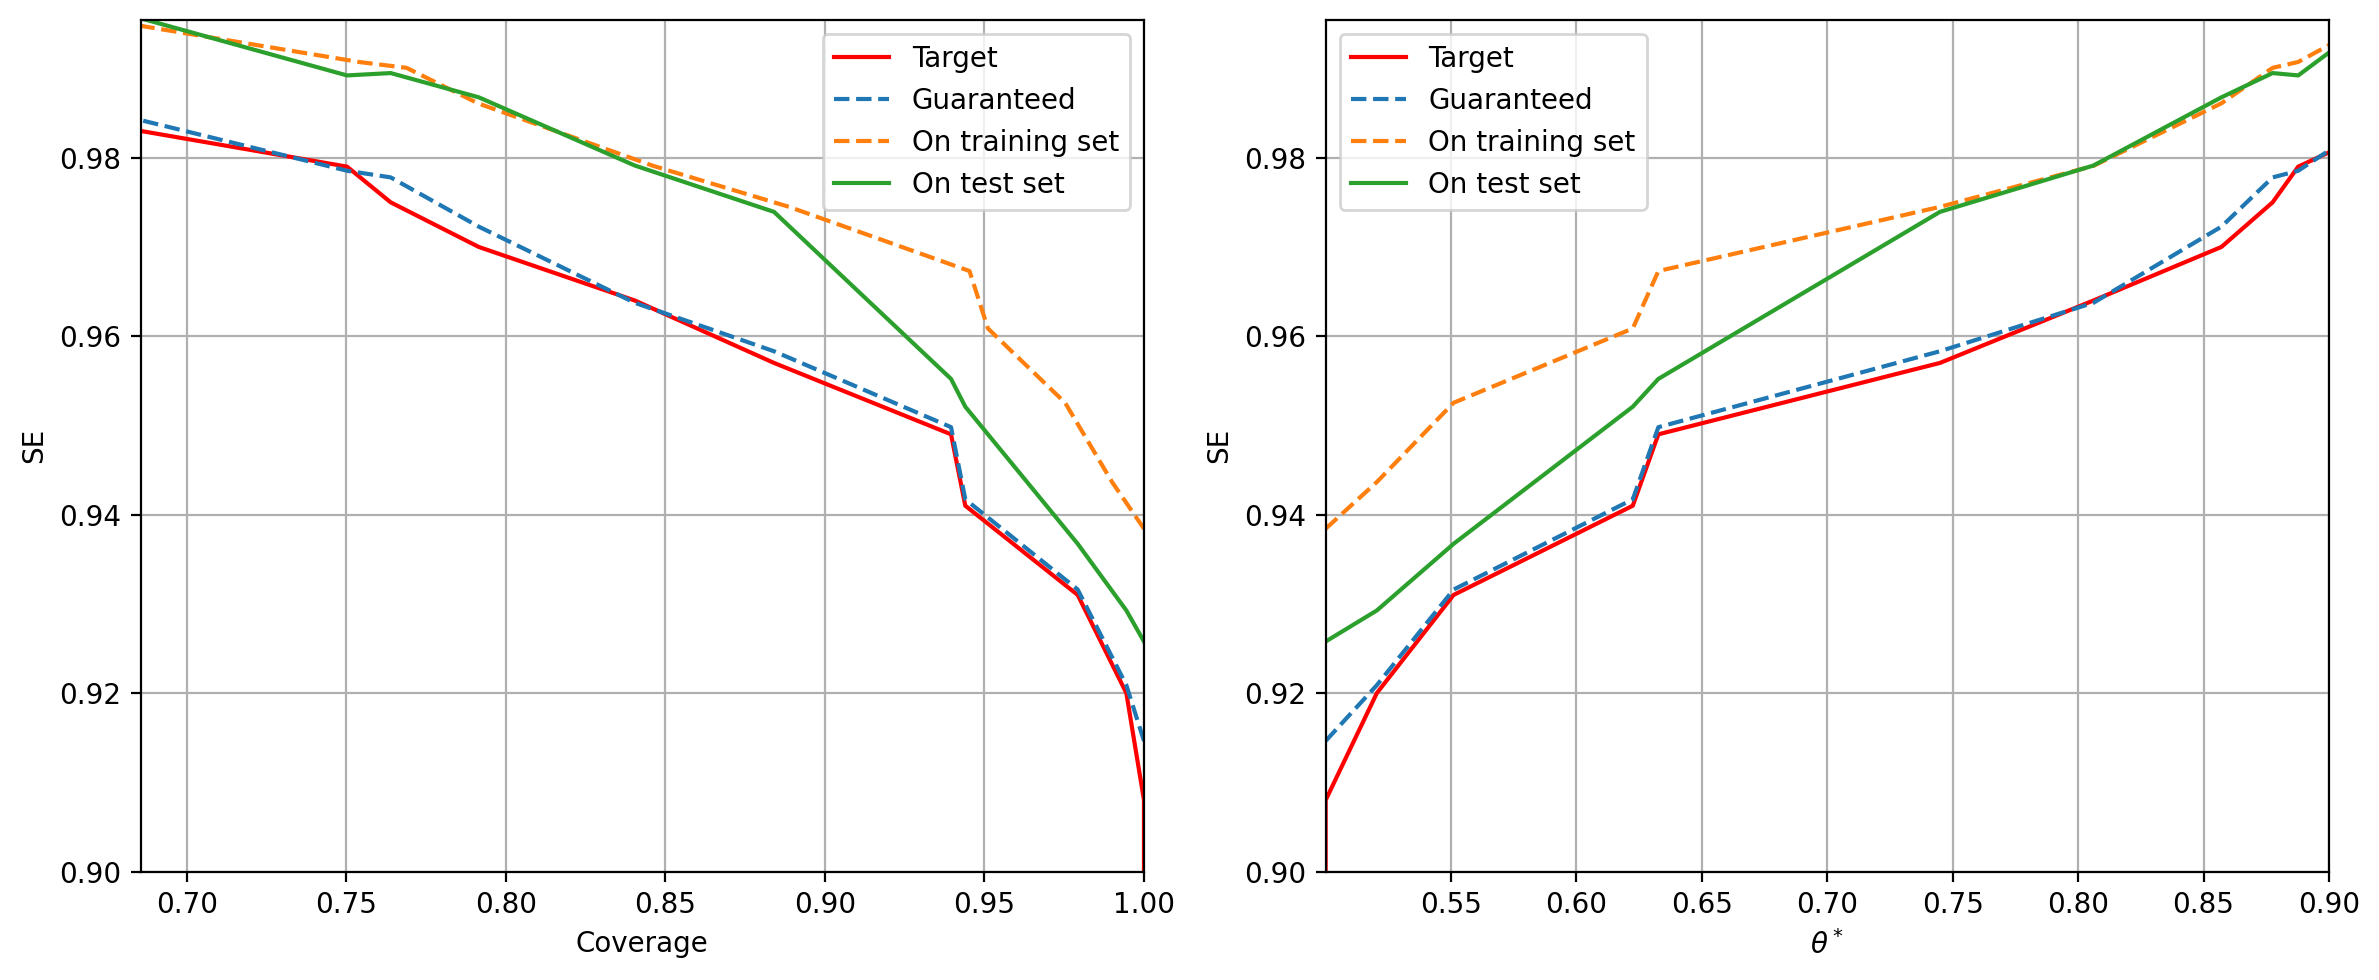

In [12]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SE', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SE', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),0.9], ylim=[0.9,max(results.train_metric)])

### <font color = 'orange'> 3.5. __SP__

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
1,0.730,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
2,0.757,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
3,0.782,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
4,0.805,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
5,0.827,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
6,0.846,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
7,0.864,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
8,0.880,0.880356,0.500024,0.903743,1.000000,0.901176,1.000000
9,0.895,0.894504,0.581652,0.916551,0.965028,0.912429,0.966605


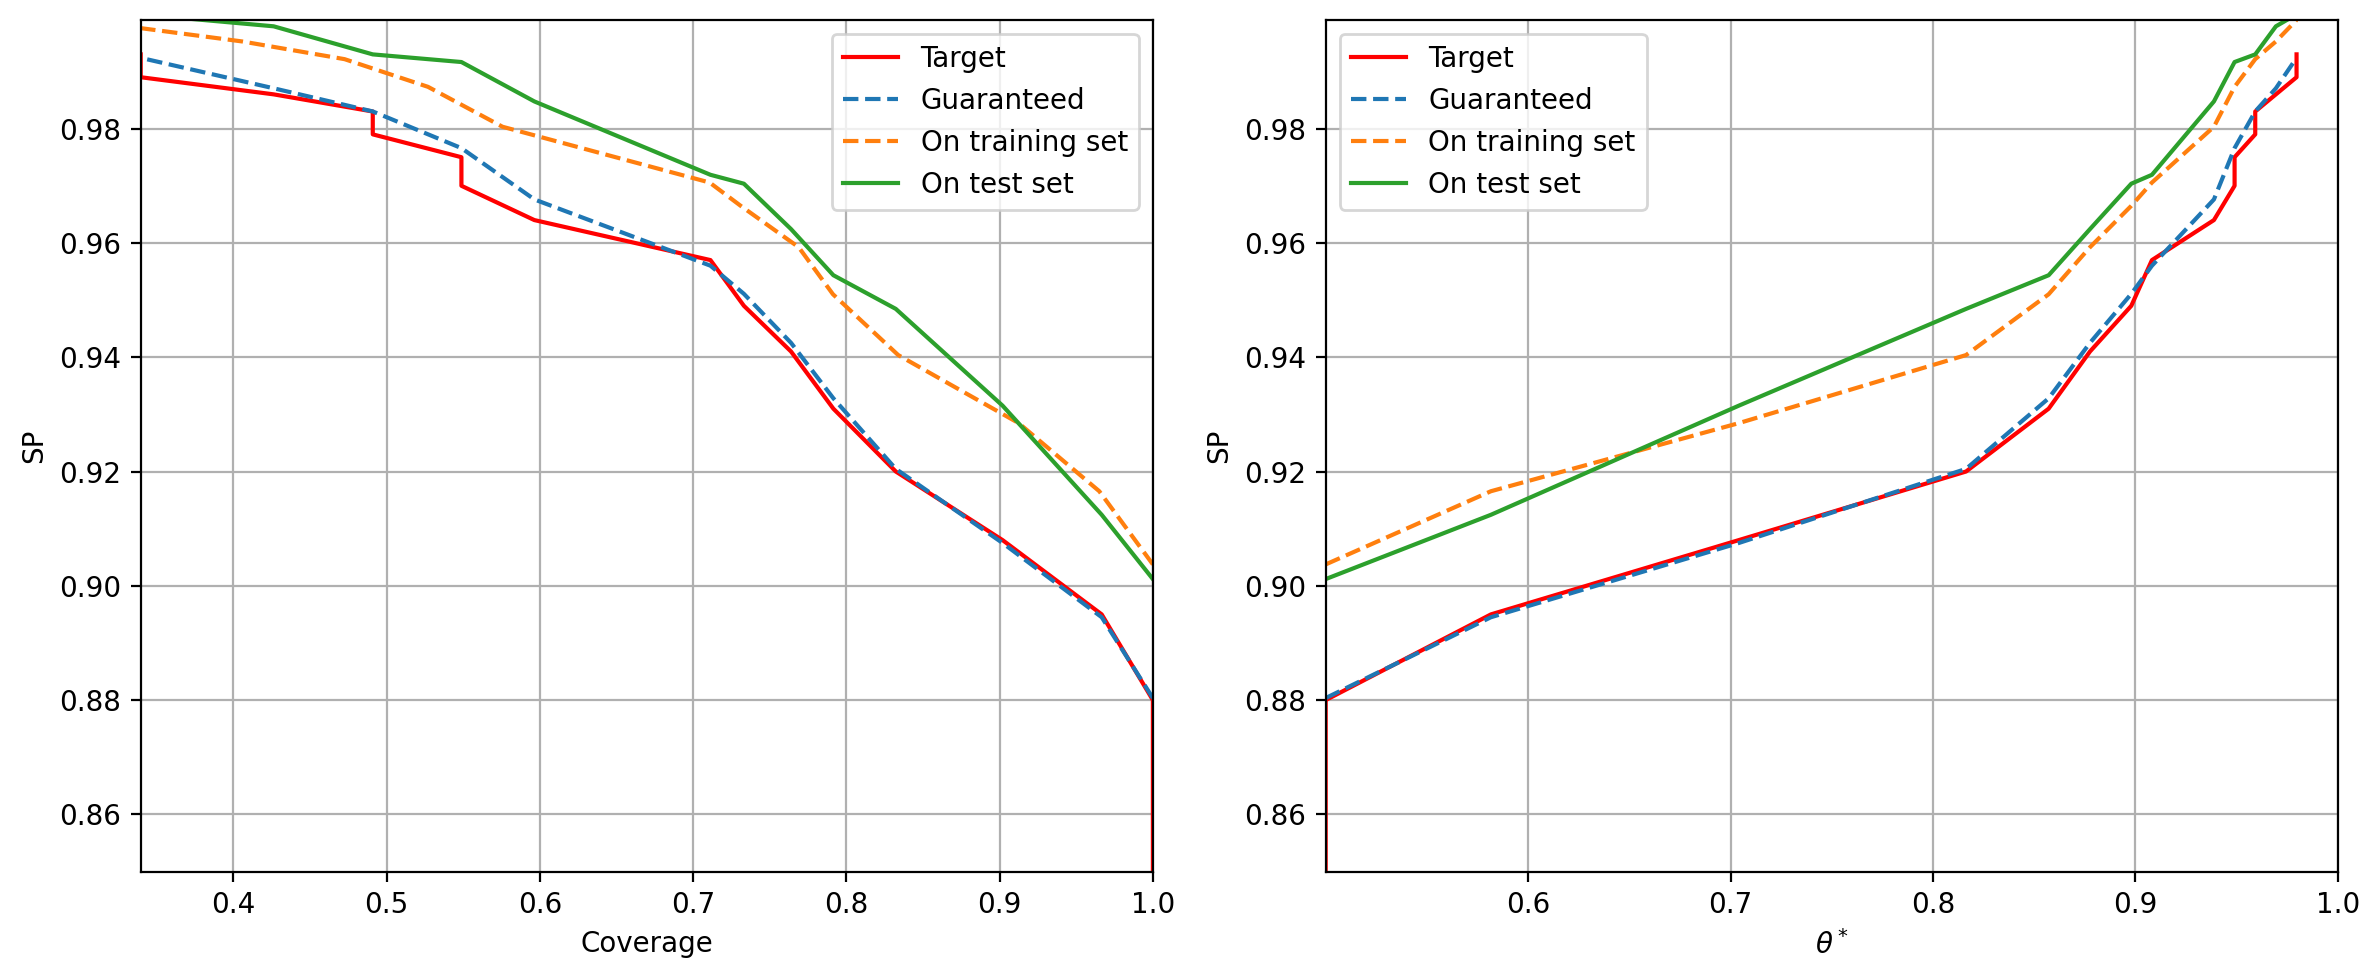

In [13]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SP', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SP', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0.85,max(results.train_metric)])